In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm 
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.lib import grdevices
from IPython.display import Image, display
import rpy2.robjects.packages as pkgs
from statsmodels.stats.multitest import multipletests
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import os
from rpy2.robjects.vectors import StrVector

utils = pkgs.importr('utils')
# utils.chooseCRANmirror(ind=1)  # Select the first CRAN mirror
# required_packages = StrVector(['lmerTest', 'performance'])#, 'dplyr', 'effectsize', 'emmeans', 'tidyr', 'ggplot2', 'performance', 'nlme', 'report', 'modelbased'])
# utils.install_packages(required_packages)

def display_r_plot(plot):
    with grdevices.render_to_bytesio(grdevices.png, width=512, height=512, res=72) as img:
        ro.r.print(plot)
        
    img.seek(0)
    image = Image(data=img.read(), format='png')
    display(image)
    return image

# pandas2ri.activate()
# # pkgs.importr('car')
# # pkgs.importr('effectsize')
# # pkgs.importr('emmeans')
# pkgs.importr('lmerTest')
# pkgs.importr('dplyr')
# # pkgs.importr('tidyr')
# pkgs.importr('ggplot2')
# pkgs.importr('performance')
# # pkgs.importr('nlme')
# # pkgs.importr('report')
# # pkgs.importr('modelbased')

In [46]:
DATA_ROOT = 'Experiment/ParticipantData/fNIRS/FilteredData/'
files = [f for f in os.listdir(DATA_ROOT) if f.endswith('.csv') and '_b.csv' not in f]

dfs = []
for f in files:
    sub_df = pd.read_csv(os.path.join(DATA_ROOT, f))
    sub_df['condition'] = f.split('_')[1]
    dfs.append(sub_df)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'trial_id', 'MARKER'])
df = df[['pid', 'condition', 'time'] + [k for k in df.keys() if k not in ['pid', 'condition', 'time']]]

df = df.melt(id_vars=['pid', 'condition', 'time'], var_name='SIDE_WLEN_MEAS', value_name='value')

df[['SIDE', 'WLEN', 'MEAS']] = df['SIDE_WLEN_MEAS'].str.split('_', expand=True)
df = df.drop(columns=['SIDE_WLEN_MEAS'])

df.condition.unique()

df['DOMAIN'] = df['condition'].str[0]
df['INTER'] = df['condition'].str[1:]
df = df.drop(columns=['condition'])

df = df[(df.WLEN == 'O') & (df.MEAS == 'DSI')].drop(columns=['WLEN', 'MEAS'])

# df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
df

,pid,time,value,SIDE,DOMAIN,INTER
0,22,2024-09-27 22:19:47.281618176,1.317972,L,F,W
1,22,2024-09-27 22:19:47.346659840,1.324740,L,F,W
2,22,2024-09-27 22:19:47.410644992,1.332869,L,F,W
3,22,2024-09-27 22:19:47.471101184,1.342102,L,F,W
4,22,2024-09-27 22:19:47.553235968,1.352246,L,F,W
...,...,...,...,...,...,...
454145,14,2024-09-20 21:30:42.653758976,0.574864,R,F,P
454146,14,2024-09-20 21:30:42.722071808,0.537369,R,F,P
454147,14,2024-09-20 21:30:42.789837824,0.500480,R,F,P
454148,14,2024-09-20 21:30:42.854604032,0.464219,R,F,P


In [ ]:
DATA_ROOT = 'Experiment/ParticipantData/fNIRS/LabeledData/'
files = [f for f in os.listdir(DATA_ROOT) if f.endswith('.csv') and '_b.csv' not in f]

dfs = []
for f in files:
    sub_df = pd.read_csv(os.path.join(DATA_ROOT, f))
    sub_df['condition'] = f.split('_')[1]
    dfs.append(sub_df)
df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'trial_id', 'MARKER', 'dateTimestamps', 'floatTimestamps',
       'episode', 'actions', 'rewards', 'discounted_rewards',
       'chosen_actions', 'optimal_actions', 'desired_goal', 'states'])

# df['LABEL'] = df['binary_optimal'].apply(lambda x: 'O' if x == 0 else 'S')

df = df[['pid', 'condition', 'time'] + [k for k in df.keys() if k not in ['pid', 'condition', 'time']]]

df = df.melt(id_vars=['pid', 'condition', 'time'], var_name='LABEL_WLEN_MEAS', value_name='value')

# df[['LABEL', 'WLEN', 'MEAS']] = df['LABEL_WLEN_MEAS'].str.split('_', expand=True)
# df = df.drop(columns=['LABEL_WLEN_MEAS'])
# df.condition.unique()

# df['DOMAIN'] = df['condition'].str[0]
# df['INTER'] = df['condition'].str[1:]
# df = df.drop(columns=['condition'])

# df = df[(df.WLEN == 'O') & (df.MEAS == 'DSI')].drop(columns=['WLEN', 'MEAS'])

# # df = df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
# df.reset_index(drop=True, inplace=True)

df


,pid,condition,time,LABEL_WLEN_MEAS,value,LABEL,WLEN,MEAS
0,12,RW,2024-09-19 22:40:47.642006016,binary_optimal,0,binary,optimal,None
1,12,RW,2024-09-19 22:40:47.704493824,binary_optimal,0,binary,optimal,None
2,12,RW,2024-09-19 22:40:47.785742848,binary_optimal,0,binary,optimal,None
3,12,RW,2024-09-19 22:40:47.844544000,binary_optimal,0,binary,optimal,None
4,12,RW,2024-09-19 22:40:48.784873984,binary_optimal,0,binary,optimal,None
...,...,...,...,...,...,...,...,...
1060015,18,LP,2024-09-25 22:42:41.427106048,discrete_optimal,0,discrete,optimal,None
1060016,18,LP,2024-09-25 22:42:41.489134080,discrete_optimal,2,discrete,optimal,None
1060017,18,LP,2024-09-25 22:42:41.566807040,discrete_optimal,2,discrete,optimal,None
1060018,18,LP,2024-09-25 22:42:41.634912000,discrete_optimal,2,discrete,optimal,None


In [61]:
from tqdm import tqdm
from mne.time_frequency import psd_array_multitaper,  tfr_array_morlet
from scipy.integrate import simpson

# VERY LOW FREQUENCY OSCILLATIONS
# HIGHER VLFO -> lower prefrontal activation

def freq_transform(fnirs_data, fs=5.2084):
    # VERY LOW FREQUENCY OSCILLATIONS
    # 0.02 - 50seconds
    # 0.07 - 14seconds
    psds, freqs = psd_array_multitaper(fnirs_data, 
                                        sfreq=fs, fmin=0.02, fmax=0.07,
                                        adaptive=True, low_bias=True, normalization='length',
                                        max_iter=2000, verbose="Warning")

    return simpson(psds, dx=freqs[1] - freqs[0])

df.tail(10)

,pid,condition,binary_optimal,time,value,LABEL,DOMAIN,INTER
163070,18,LP,0,2024-09-25 22:42:40.238171136,-2.300255,O,L,P
163071,18,LP,0,2024-09-25 22:42:40.299817216,-2.237664,O,L,P
163072,18,LP,0,2024-09-25 22:42:40.376591104,-2.162761,O,L,P
163073,18,LP,0,2024-09-25 22:42:41.295695104,-2.077788,O,L,P
163074,18,LP,0,2024-09-25 22:42:41.353028096,-1.985384,O,L,P
163075,18,LP,0,2024-09-25 22:42:41.427106048,-1.888414,O,L,P
163076,18,LP,1,2024-09-25 22:42:41.489134080,-1.78981,S,L,P
163077,18,LP,1,2024-09-25 22:42:41.566807040,-1.69239,S,L,P
163078,18,LP,1,2024-09-25 22:42:41.634912000,-1.598671,S,L,P
163079,18,LP,1,2024-09-25 22:42:41.702728960,-1.510674,S,L,P


In [62]:
freq_df = df.groupby(['pid', 'LABEL', 'DOMAIN', 'INTER']).value.apply(freq_transform).rename('vlf').reset_index()
freq_df.vlf = np.log(freq_df.vlf)
freq_df = freq_df.groupby(['pid', 'SIDE', 'DOMAIN', 'INTER']).mean(numeric_only=True).reset_index()
freq_df.tail(1)

IndexError: index 1 is out of bounds for axis 0 with size 1

/var/folders/bk/m5wzpcwd46xdzs4b0n4hp9ym0000gn/T/ipykernel_48234/1122820885.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(kind='point', col="SIDE", data=freq_df, x='DOMAIN', y='vlf', hue='INTER', join=False, dodge=True)
/Users/juliasantaniello/opt/anaconda3/envs/hitlbci/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


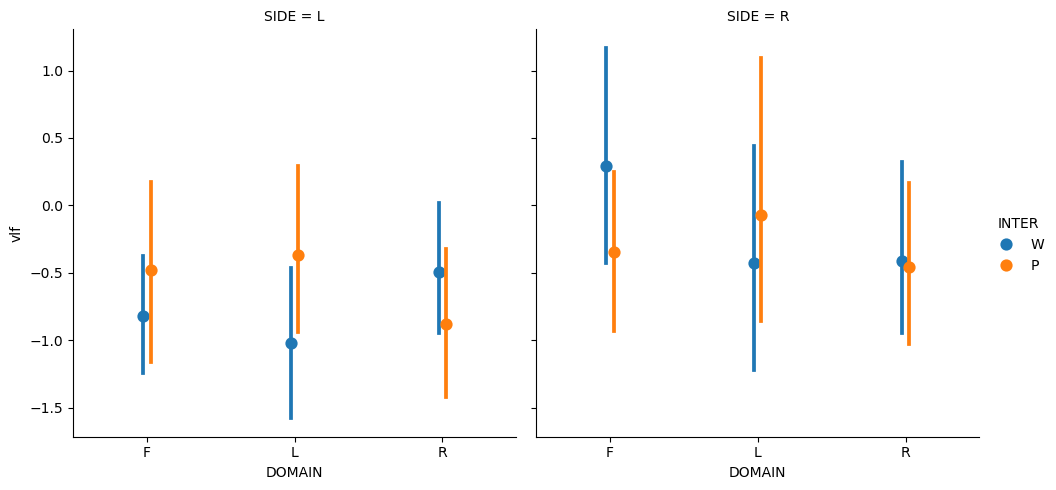

In [28]:
sns.catplot(kind='point', col="SIDE", data=freq_df, x='DOMAIN', y='vlf', hue='INTER', join=False, dodge=True)

<Axes: >

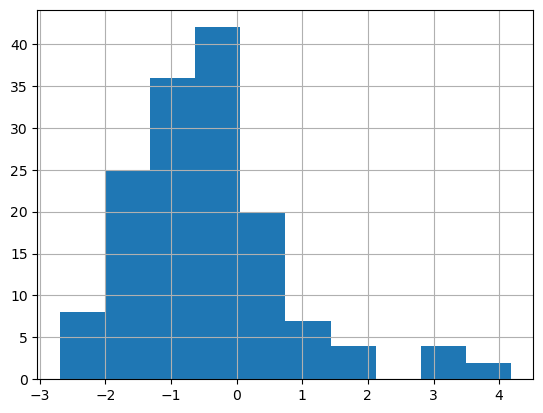

In [6]:
freq_df.vlf.hist()

In [7]:
r_func = ro.r('''
    function(df) {
        df$pid <- as.factor(df$pid)
        df$DOMAIN <- as.factor(df$DOMAIN)
        df$INTER <- as.factor(df$INTER)

        # linear mixed model
        m <- lmerTest::lmer(vlf ~ DOMAIN * INTER + (1+DOMAIN|pid), data=df)
       
        # linear model
        # m <- lm(vlf ~ DOMAIN * INTER, data=df)
        print(summary(m))

        ava <- anova(m) 
        chk_plot <- check_model(m)

        return (list(ava, chk_plot))

    }
''')
for side, side_df in freq_df.groupby('SIDE'):
    if side == 'L': 
        continue
    ava, chk_plot = r_func(side_df)
    print("A")

    display_r_plot(chk_plot)
    
    ava = ro.conversion.rpy2py(ava)
    display(ava)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: vlf ~ DOMAIN * INTER + (1 + DOMAIN | pid)
   Data: df

REML criterion at convergence: 181.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.90648 -0.32323 -0.06209  0.33477  1.81093 

Random effects:
 Groups   Name        Variance Std.Dev. Corr       
 pid      (Intercept) 1.6457   1.2828              
          DOMAINL     0.3604   0.6003    0.38      
          DOMAINR     0.2949   0.5431   -0.18  0.37
 Residual             0.1408   0.3752              
Number of obs: 74, groups:  pid, 23

Fixed effects:
                Estimate Std. Error        df t value Pr(>|t|)
(Intercept)    -0.033492   0.317003 30.513971  -0.106    0.917
DOMAINL         0.044843   0.261412 32.425984   0.172    0.865
DOMAINR        -0.332222   0.239271 34.804859  -1.388    0.174
INTERW          0.104921   0.209826 24.886922   0.500    0.621
DOMAINL:INTERW  0.002654   0.302984 24.691220   0.009    

R[write to console]: Error: Following variable(s) were not found: SE_factor
  Possibly misspelled?



RRuntimeError: Error: Following variable(s) were not found: SE_factor
  Possibly misspelled?


In [ ]:
sns.catplot(kind='point', data=df, col='MEAS', row='SIDE', x='condition', hue='WLEN', y='value', join=False)